![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Flux Processing Chain (here starting Level-4.1)
</b>
</br>
  
</span>
<p>Post-processing of EddyPro <i>_fluxnet_</i> output files</p>

---
**Notebook version**: `11.0` (19 Nov 2025)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

In [1]:
from datetime import datetime

</br>

# Load previous `fpc` instance

In [2]:
import pickle
# 1. Load the instance from the pickle file
file_path = '31_fpcInstance_QCF11+TrimNT-5.pkl'
with open(file_path, 'rb') as file:
    fpc = pickle.load(file)

In [3]:
fpc

</br>

</br>

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# 🟢Level-4.1: GAP-FILLING

- Introduced in `diive` v0.85.0, gap-filling can now be done using both random forest and MDS
- For gap-filling using MDS, make sure that variables are in the required units: short-wave incoming radiation in `W m-2`, air temperature in `°C`, VPD in `hPa`

Parameters:
- `mds_settings` are parameters for the MDS gap-filling method, [see docstring here for more details](https://github.com/holukas/diive/blob/main/diive/pkgs/gapfilling/mds.py)
- `rf_settings` are parameters for scikit's `RandomForestRegressor` model, [see their official documentation for allowed parameters](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
- `ml_feature_settings` are general settings for machine-learning models (such as random forest)

## 🔸Long-term random forest

In [4]:
FEATURES = ["TA_T1_47_1_gfXG", "SW_IN_T1_47_1_gfXG", "VPD_T1_47_1_gfXG"]
fpc.level41_longterm_random_forest(
    features=FEATURES,
    sanitize_timestamp=True,
    features_lag=[-1, 1],
    features_lag_stepsize=1,
    features_lag_exclude_cols=None,
    reduce_features=False,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    perm_n_repeats=10,
    verbose=True,
    n_estimators=100,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=10,
    n_jobs=1,
    random_state=42,
)



Starting gap-filling for
NEE_L3.1_L3.3_CUT_50_QCF
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Adding new data columns ...
++ Added new columns with lagged variants for: ['TA_T1_47_1_gfXG', 'SW_IN_T1_47_1_gfXG', 'VPD_T1_47_1_gfXG'] (lags between -1 and 1 with stepsize 1), no lagged variants for: ['NEE_L3.1_L3.3_CUT_50_QCF']. Shifting the time series created gaps which were then filled with the nearest value.
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 276211.

Sanitizing timestamp ...
>>> Validating timestamp naming of timestamp column TIMESTAMP_MIDDLE ... Timestamp name OK.
>>> Converting timestamp TIMESTAMP_MIDDLE to datetime ... OK
>>> All rows have timestamp TIMESTAMP_MIDDL

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\gapfilling\longterm.py:297: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self._gapfilling_df = pd.concat([self._gapfilling_df, rfts.gapfilling_df_[keepyear]], axis=0)


## 🔸MDS (Marginal Distribution Sampling)

In [5]:
# fpc.level41_mds(
#     swin="SW_IN_T1_47_1_gfXG",
#     ta="TA_T1_47_1_gfXG",
#     vpd="VPD_T1_47_1_gfXG",
#     swin_tol=[20, 50],
#     ta_tol=2.5,
#     vpd_tol=0.5,
#     avg_min_n_vals=5
# )

## Get results
- Results from the flux processing chain can be accessed using `.get_data()`
- This returns a dataframe containing all input data and all newly generated variables, such as quality flags, quality-filtered fluxes and gap-filled fluxes

In [6]:
# results = fpc.get_data(verbose=1)
# results

## Model scores

### Model scores and details on test data

In [7]:
# Show train/test details
print(fpc.report_traintest_model_scores())
print(fpc.report_traintest_details())
# fpc.report_traintest_model_scores(outpath=".")  # Save in current folder
# fpc.report_traintest_details(outpath=".")  # Save in current folder


MODEL SCORES from TRAINING/TESTING (long_term_random_forest): 
 trained on training data, tested on unseen test data CUT_50
            2004       2005       2006       2007       2008       2009  ...       2014       2015       2016       2017       2018       2019
mae     3.528332   3.528332   3.611048   3.714603   3.632837   3.665077  ...   4.702701   4.697328   4.482114   4.567756   4.040180   4.040180
medae   2.331460   2.331460   2.309093   2.383906   2.330787   2.389308  ...   2.997427   2.833121   2.782239   2.769701   2.669436   2.669436
mse    27.348989  27.348989  29.347962  31.281507  29.878551  29.482943  ...  50.001259  52.311869  46.251776  48.115982  35.109014  35.109014
rmse    5.229626   5.229626   5.417376   5.592987   5.466128   5.429820  ...   7.071157   7.232694   6.800866   6.936568   5.925286   5.925286
mape    2.688503   2.688503  15.616007   2.985112   3.715197   2.882422  ...   1.977860   9.771363   2.330466   2.259986   4.333548   4.333548
maxe   38.900952 

### Model scores on all data

In [8]:
fpc.report_gapfilling_model_scores()
# fpc.report_gapfilling_model_scores(outpath=".")  # Save in current folder


MODEL SCORES (long_term_random_forest): CUT_50
            2004       2005       2006       2007       2008       2009  ...       2014       2015       2016       2017       2018       2019
mae     3.003487   3.003487   3.041452   3.061317   3.141447   3.141313  ...   3.882755   3.861521   3.734747   3.741122   3.378204   3.378204
medae   1.931239   1.931239   1.947108   1.905859   1.973451   1.984558  ...   2.392707   2.386246   2.275842   2.320303   2.145300   2.145300
mse    20.093267  20.093267  21.244521  22.130193  23.393180  22.865882  ...  34.937335  35.368929  33.007904  33.273161  25.859190  25.859190
rmse    4.482551   4.482551   4.609178   4.704274   4.836650   4.781828  ...   5.910781   5.947178   5.745251   5.768289   5.085193   5.085193
mape    4.822814   4.822814   5.527296   4.119484   2.345459   2.267757  ...   5.148713   4.379626   2.846065   2.777275   2.617206   2.617206
maxe   38.900952  38.900952  43.022027  46.378861  44.335038  39.553719  ...  47.068166  54.09

During long-term gap-filling, different years are pooled together to predict one central year, i.e., multiple models are used.  
The used data pools can be display with:

In [9]:
fpc.report_gapfilling_poolyears()

DATA POOLS USED FOR MACHINE-LEARNING GAP-FILLING:
2004: long_term_random_forest used data from [2004, 2005, 2006] for gap-filling NEE_L3.1_L3.3_CUT_50_QCF and producing --> NEE_L3.1_L3.3_CUT_50_QCF_gfRF
2005: long_term_random_forest used data from [2004, 2005, 2006] for gap-filling NEE_L3.1_L3.3_CUT_50_QCF and producing --> NEE_L3.1_L3.3_CUT_50_QCF_gfRF
2006: long_term_random_forest used data from [2005, 2006, 2007] for gap-filling NEE_L3.1_L3.3_CUT_50_QCF and producing --> NEE_L3.1_L3.3_CUT_50_QCF_gfRF
2007: long_term_random_forest used data from [2006, 2007, 2008] for gap-filling NEE_L3.1_L3.3_CUT_50_QCF and producing --> NEE_L3.1_L3.3_CUT_50_QCF_gfRF
2008: long_term_random_forest used data from [2007, 2008, 2009] for gap-filling NEE_L3.1_L3.3_CUT_50_QCF and producing --> NEE_L3.1_L3.3_CUT_50_QCF_gfRF
2009: long_term_random_forest used data from [2008, 2009, 2010] for gap-filling NEE_L3.1_L3.3_CUT_50_QCF and producing --> NEE_L3.1_L3.3_CUT_50_QCF_gfRF
2010: long_term_random_forest us

In [10]:
fpc.report_gapfilling_feature_importances()  # Save in current folder
# fpc.report_gapfilling_feature_importances(outpath=".")  # Save in current folder


FEATURE IMPORTANCES (long_term_random_forest): CUT_50
YEAR                       2004      2005      2006      2007      2008      2009  ...      2014      2015      2016      2017      2018      2019
FEATURE                                                                            ...                                                            
.DOY_COS               0.435783  0.435783  0.177355  0.350229  0.457849  0.196724  ...  0.446124  0.446351  0.499514  0.187734  0.294368  0.294368
SW_IN_T1_47_1_gfXG     0.201483  0.201483  0.321626  0.463860  0.484050  0.284089  ...  0.383049  0.431974  0.448861  0.660953  0.538810  0.538810
.HOUR_COS              0.138845  0.138845  0.184810  0.195227  0.209953  0.210326  ...  0.144155  0.135928  0.203107  0.195477  0.163834  0.163834
.DOY_SIN               0.136180  0.136180  0.066428  0.066571  0.037560  0.022566  ...  0.071920  0.050230  0.052874  0.047813  0.029756  0.029756
.SW_IN_T1_47_1_gfXG-1  0.115891  0.115891  0.082304  0.070459  

## Names of gap-filled variables


In [11]:
print("Used model, USTAR scenario, non-gapfilled variable and gap-filled variable:")
fpc.report_gapfilling_variables()

Used model, USTAR scenario, non-gapfilled variable and gap-filled variable:
long_term_random_forest (CUT_50): NEE_L3.1_L3.3_CUT_50_QCF -> NEE_L3.1_L3.3_CUT_50_QCF_gfRF


In [12]:
gapfilled_names = fpc.get_gapfilled_names()
gapfilled_names

['NEE_L3.1_L3.3_CUT_50_QCF_gfRF']

Gap-filled data can also be accessed directly. To get all gap-filled variables and also the same variables before gap-filling in a dataframe, use `.get_gapfilled_variables()`: 

In [13]:
gapfilled_vars = fpc.get_gapfilled_variables()
gapfilled_vars.head(3)

,NEE_L3.1_L3.3_CUT_50_QCF_gfRF,NEE_L3.1_L3.3_CUT_50_QCF
TIMESTAMP_MIDDLE,,
2004-03-30 14:45:00,-1.589580,NaN
2004-03-30 15:15:00,-0.929001,NaN
2004-03-30 15:45:00,-0.929001,NaN


The names of the flux that was gap-filled can be accessed like this:

In [14]:
nongapfilled_names = fpc.get_nongapfilled_names()
nongapfilled_names

['NEE_L3.1_L3.3_CUT_50_QCF']

## Plots

### Heatmaps

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\fluxprocessingchain\fluxprocessingchain.py:502: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


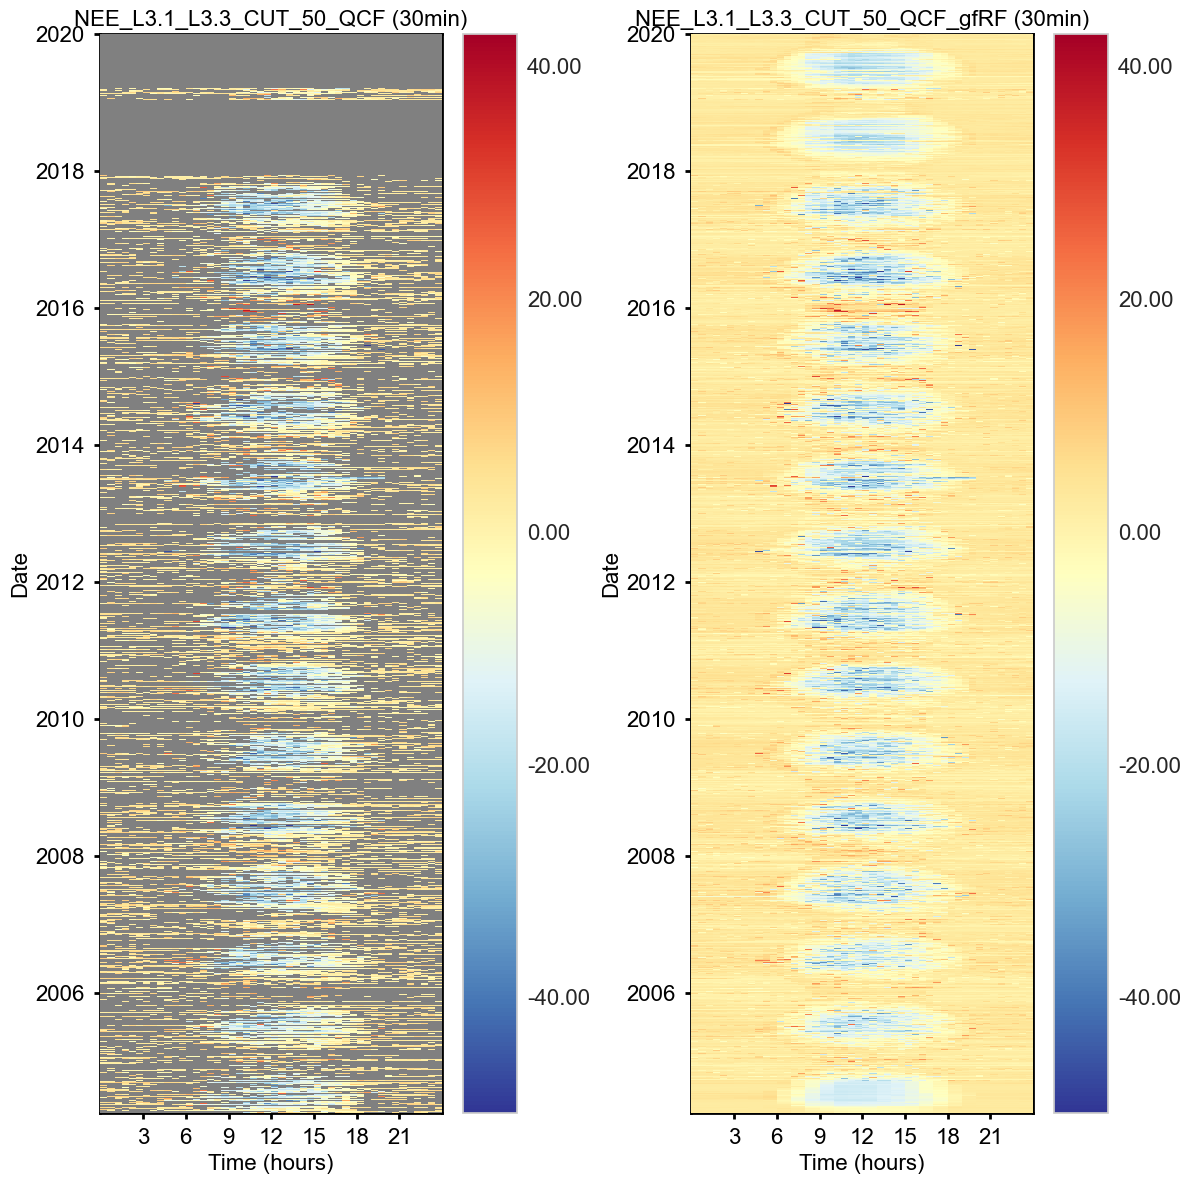

In [15]:
fpc.showplot_gapfilled_heatmap()

### Cumulatives per year

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\cumulative.py:145: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()


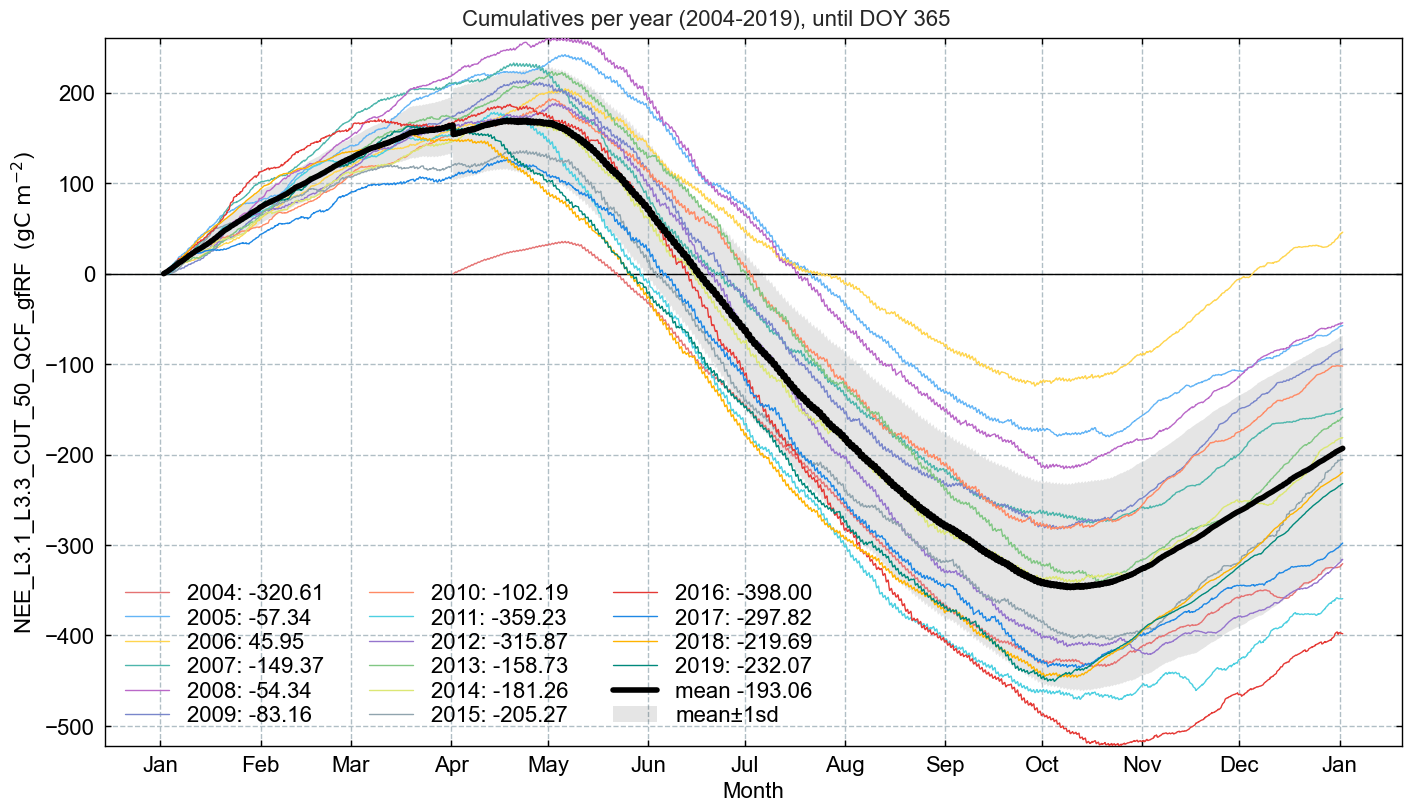

In [16]:
fpc.showplot_gapfilled_cumulative(gain=0.02161926, units=r'($\mathrm{gC\ m^{-2}}$)', per_year=True)

### Cumulative across all data 

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\core\plotting\cumulative.py:251: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()


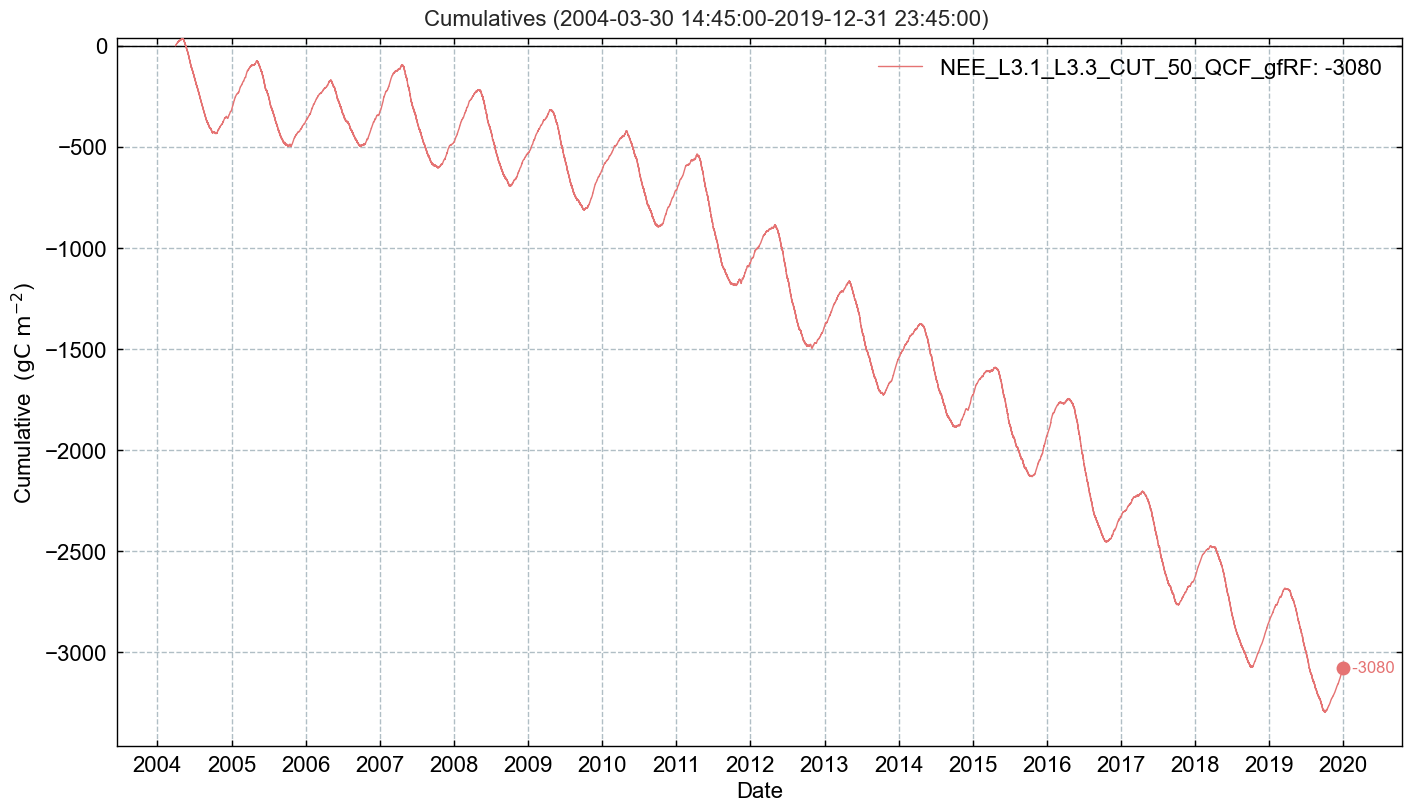

In [17]:
fpc.showplot_gapfilled_cumulative(gain=0.02161926, units=r'($\mathrm{gC\ m^{-2}}$)', per_year=False)

### ML Feature ranks per year (machine learning models only)

F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\gapfilling\longterm.py:268: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(row.index, row.values, "o", marker=verts, ms=20,
F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\pkgs\gapfilling\longterm.py:287: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


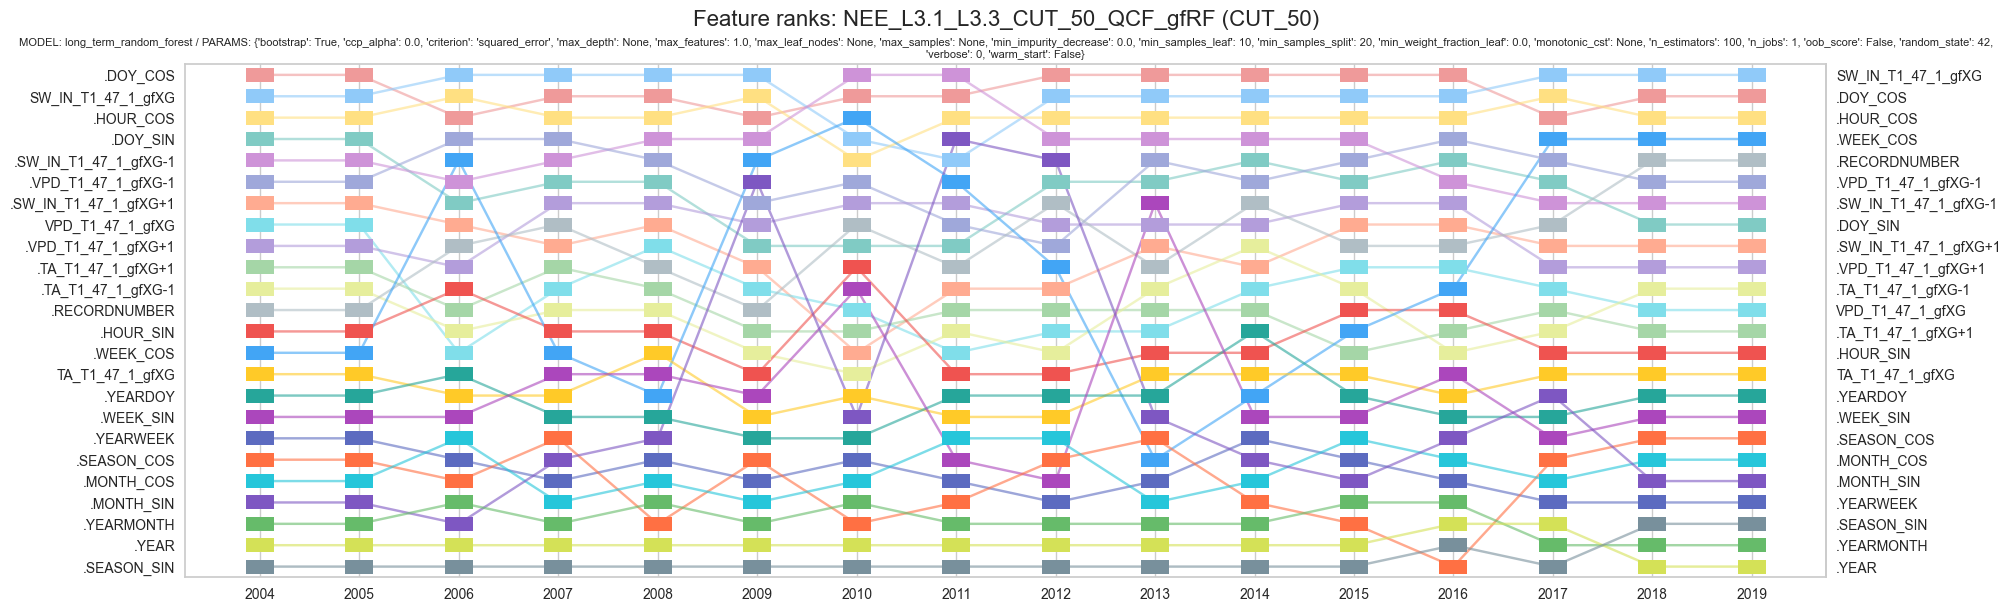

In [18]:
fpc.showplot_feature_ranks_per_year()

### MDS gap-filling qualities (MDS only, otherwise skipped)

In [19]:
fpc.showplot_mds_gapfilling_qualities()

</br>

</br>

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# SAVE RESULTS TO FILE

- Save results to file for futher processing
- This can be useful if you want to use the data in another software, e.g. continuing post-processing using the library `ReddyProc` in `R` 
- `Parquet` format is recommended for large datasets

</br>

## Option 1: Save complete data (input data and results) to CSV (large and slow)

In [20]:
# results.to_csv("FluxProcessingChain_L4.1.csv")

</br>

## Option 2: Save input data and results to Parquet (small and fast)
- Needed if you want to continue post-processing in notebooks
- Can also be used in `R` with the `arrow` package

In [21]:
# save_parquet(data=results, filename="02_FirstResults_FluxProcessingChain_L4.1")

</br>

</br>

<div style="
    height: 30px; /* Adjust height as desired */
    background: linear-gradient(135deg, #FF6B6B 0%, #FFE66D 100%); /* Warm gradient */
    background-image: 
        radial-gradient(circle at 100% 150%, #FF6B6B 0%, #FFE66D 100%),
        linear-gradient(to right, rgba(255,255,255,0.1) 1px, transparent 1px),
        linear-gradient(to bottom, rgba(255,255,255,0.1) 1px, transparent 1px);
    background-size: 100% 100%, 15px 15px, 15px 15px; /* Adjust pattern size */
    border-radius: 8px;
    box-shadow: 0 4px 8px rgba(0,0,0,0.1);
"></div>

# ✅END OF NOTEBOOK

Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [22]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-12-01 17:43:15
